# Imports and Configuration

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import cv2 
import pywt # For Wavelet Transform
import timm # For the ViT backbone
import matplotlib.pyplot as plt

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters aligned with Battocchio et al. and Corvi et al.
NUM_FRAMES = 8       # Temporal batch size
IMG_SIZE = 224       # Standard ViT input size
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

Using device: cuda


# Wavelet Augmentation Function


In [8]:
def wavelet_blend(fake_frame, real_frame):
    """
    Applies Haar Wavelet decomposition and replaces the low-frequency 
    and H/V high-frequency components of 'fake_frame' with those from 'real_frame'.
    Keeps only the Diagonal details (cD) of the fake frame.
    """
    # 1. Make sure tensors are on CPU and convert them to numpy
    # [C, H, W] -> [H, W, C]
    fake_np = fake_frame.detach().cpu().numpy().transpose(1, 2, 0) 
    real_np = real_frame.detach().cpu().numpy().transpose(1, 2, 0)
    
    aug_frame = np.zeros_like(fake_np)
    
    # 2. Iterate over channels (RGB)
    for ch in range(3): 
        # 1-level decomposition (Haar)
        coeffs_fake = pywt.dwt2(fake_np[:,:,ch], 'haar')
        coeffs_real = pywt.dwt2(real_np[:,:,ch], 'haar')
        
        # cA = Approximation (Low frequencies)
        # cH = Horizontal details
        # cV = Vertical details
        # cD = Diagonal details (the ones we want to keep from the Fake!)
        cA_fake, (cH_fake, cV_fake, cD_fake) = coeffs_fake
        cA_real, (cH_real, cV_real, cD_real) = coeffs_real
        
        # MIXING STRATEGY:
        # Keep cD (Diagonal) from the FAKE (contains typical checkerboard artifacts)
        # Replace everything else with the REAL (removes semantic bias)
        new_coeffs = (cA_real, (cH_real, cV_real, cD_fake)) 
        
        # Reconstruction
        rec = pywt.idwt2(new_coeffs, 'haar')
        
        # Handle odd dimensions (idwt2 may be off by 1 pixel if input size is odd)
        # Coerce the shape to match the input
        h, w = fake_np.shape[:2]
        aug_frame[:,:,ch] = rec[:h, :w]
        
    # 3. SAFETY CLIP (Essential): Bring values back to the [0, 1] range
    aug_frame = np.clip(aug_frame, 0.0, 1.0)
        
    # Return float32 tensor [C, H, W]
    return torch.from_numpy(aug_frame.transpose(2, 0, 1)).float()


# Custom Dataset Class

In [9]:
class FakeVideoDataset(Dataset):
    def __init__(self, video_paths, labels, real_video_paths=None, transform=None, num_frames=8, is_train=True):
        """
        Args:
            video_paths: List of file paths to videos (mixed Real and Fake).
            labels: List of labels corresponding to video_paths (0 for Real, 1 for Fake).
            real_video_paths: List of ONLY real video paths. Needed for Wavelet Augmentation 
                              to sample a reference 'source' for the frequency swap.
            transform: PyTorch transforms (e.g., transforms.Compose([...])).
            num_frames: Number of frames to sample per video (default 8 for 3D-ViT).
            is_train: Boolean to enable augmentation logic.
        """
        self.video_paths = video_paths
        self.labels = labels
        # For augmentation we need a pool of real videos to sample from
        self.real_video_paths = real_video_paths if real_video_paths is not None else []
        self.transform = transform
        self.num_frames = num_frames
        self.is_train = is_train

    def load_video_frames(self, path):
        """
        Loads 'num_frames' frames uniformly sampled from the video.
        Returns a tensor: [Frames, Channels, Height, Width]
        """
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            # Fallback: return a black tensor if the video is corrupted
            print(f"Warning: Could not open {path}")
            return torch.zeros(self.num_frames, 3, 224, 224)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Handle short or empty videos
        if total_frames <= 0:
            cap.release()
            return torch.zeros(self.num_frames, 3, 224, 224)

        # Uniform sampling of indices
        # Example: if total=100 and num=8 -> [0, 12, 25, 37, 50, 62, 75, 87]
        indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                # If reading fails (e.g., unexpected EOF), use the last valid frame or a black one
                frame = np.zeros((224, 224, 3), dtype=np.uint8) if not frames else frames[-1]
            else:
                # OpenCV reads in BGR, convert to RGB
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # Resize is mandatory for ViT (224x224)
                frame = cv2.resize(frame, (224, 224))
            
            frames.append(frame)
        cap.release()

        # Stack into numpy array: [Frames, H, W, C] -> [8, 224, 224, 3]
        buffer = np.stack(frames)
        
        # Convert to PyTorch Tensor and reorder channels: [F, H, W, C] -> [F, C, H, W]
        # Note: Normalize to [0, 1] by dividing by 255.0
        video_tensor = torch.from_numpy(buffer).float().permute(0, 3, 1, 2) / 255.0
        
        return video_tensor

    def get_reference_real_video(self):
        """Selects a random real video from the pool for augmentation"""
        if not self.real_video_paths:
            return None
        rand_idx = np.random.randint(0, len(self.real_video_paths))
        return self.load_video_frames(self.real_video_paths[rand_idx])

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]
        
        video = self.load_video_frames(path) # Shape: [8, 3, 224, 224]

        # === Wavelet Augmentation Logic ===
        # Applied only during training and only to FAKE videos (label == 1)
        if self.is_train and label == 1 and len(self.real_video_paths) > 0:
            # Retrieve a reference real video
            # Note: Corvi et al. suggest videos with similar content, but
            # random sampling is a good approximation for texture bias.
            ref_video = self.get_reference_real_video()
            
            if ref_video is not None:
                # Apply augmentation frame by frame
                aug_frames = []
                for i in range(self.num_frames):
                    # We assume the function 'wavelet_blend' is defined in the previous cell
                    # as discussed in the plan.
                    f_fake = video[i] # [3, 224, 224]
                    f_real = ref_video[i] # [3, 224, 224]
                    
                    # Call to the wavelet function (implemented separately)
                    f_aug = wavelet_blend(f_fake, f_real)
                    aug_frames.append(f_aug)
                
                # Rebuild the video tensor
                video = torch.stack(aug_frames)

        # Standard Transforms (e.g., ImageNet normalization)
        if self.transform:
            # Standard torchvision transforms usually expect [C, H, W]
            # So we iterate over frames or use 3D transforms
            # Here we apply the transform to each frame
            video = torch.stack([self.transform(f) for f in video])
            
        return video, label

    def __len__(self):
        return len(self.video_paths)


# 3D-ViT Model Architecture


In [10]:
class Detector3DViT(nn.Module):
    def __init__(self, pretrained=True):
        super(Detector3DViT, self).__init__()
        
        # Load a standard ViT (ImageNet weights)
        # Battocchio uses Panda-70M, but 'vit_base_patch16_224' is the closest and most robust standard proxy.
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=pretrained)
        
        # === FREEZE BACKBONE ===
        # Key point: we freeze the weights to use it only as a feature extractor.
        # This drastically reduces training time and improves generalization.
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Classifier Head (Trainable)
        # The base ViT has an output dimension of 768.
        self.head = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3), # Dropout to prevent overfitting
            nn.Linear(512, 1) # Binary output (0=Real, 1=Fake)
        )
        
    def forward(self, x):
        # Input shape: [Batch, Frames, Channels, Height, Width] -> [B, 8, 3, 224, 224]
        b, f, c, h, w = x.shape
        
        # Merge Batch and Frames to feed everything into the 2D ViT
        x = x.view(b * f, c, h, w) 
        
        # Feature extraction
        features = self.backbone.forward_features(x) # [B*8, Tokens, Dim]
        
        # Take the CLS token (the first token that summarizes the image)
        cls_token = features[:, 0] # [B*8, 768]
        
        # Restore the temporal dimension
        cls_token = cls_token.view(b, f, -1) # [B, 8, 768]
        
        # Temporal Pooling: average features across temporal frames
        # This captures the temporal consistency of the video
        video_features = torch.mean(cls_token, dim=1) # [B, 768]
        
        # Final classification
        logits = self.head(video_features)
        return logits


# Training Setup and Loop


In [11]:
model = Detector3DViT().to(device)

# Loss for binary classification
criterion = nn.BCEWithLogitsLoss()

# Optimizer: update only the parameters of the 'head', the backbone is frozen
optimizer = optim.Adam(model.head.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for i, (videos, labels) in enumerate(loader):
        videos = videos.to(device)
        labels = labels.to(device).float().unsqueeze(1) # [Batch, 1]
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if i % 10 == 0:
            print(f"   Step {i}/{len(loader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # No gradients during validation
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total


# Training configuration and execution 

Scanning folders...
Found 200 Real and 200 Fake videos.
Dataset split: 320 Train, 80 Validation

Starting 3D-ViT training with Wavelet Augmentation...

Epoch 1/10
   Step 0/40 | Loss: 0.6937
   Step 10/40 | Loss: 0.6907
   Step 20/40 | Loss: 0.7963
   Step 30/40 | Loss: 0.6749
   Train Loss: 0.6949 | Acc: 54.37%
   Val Loss:   0.6920 | Acc: 48.75%
   Best model saved.

Epoch 2/10
   Step 0/40 | Loss: 0.5595
   Step 10/40 | Loss: 0.6032
   Step 20/40 | Loss: 0.5084
   Step 30/40 | Loss: 0.7096
   Train Loss: 0.6423 | Acc: 63.75%
   Val Loss:   0.7280 | Acc: 50.00%
   Best model saved.

Epoch 3/10
   Step 0/40 | Loss: 0.6839
   Step 10/40 | Loss: 0.7649
   Step 20/40 | Loss: 0.5936
   Step 30/40 | Loss: 0.8463
   Train Loss: 0.6323 | Acc: 63.75%
   Val Loss:   0.7583 | Acc: 42.50%

Epoch 4/10
   Step 0/40 | Loss: 0.6396
   Step 10/40 | Loss: 0.5048
   Step 20/40 | Loss: 0.6370
   Step 30/40 | Loss: 0.6924
   Train Loss: 0.5644 | Acc: 74.38%
   Val Loss:   0.7660 | Acc: 36.25%

Epoch 5/10

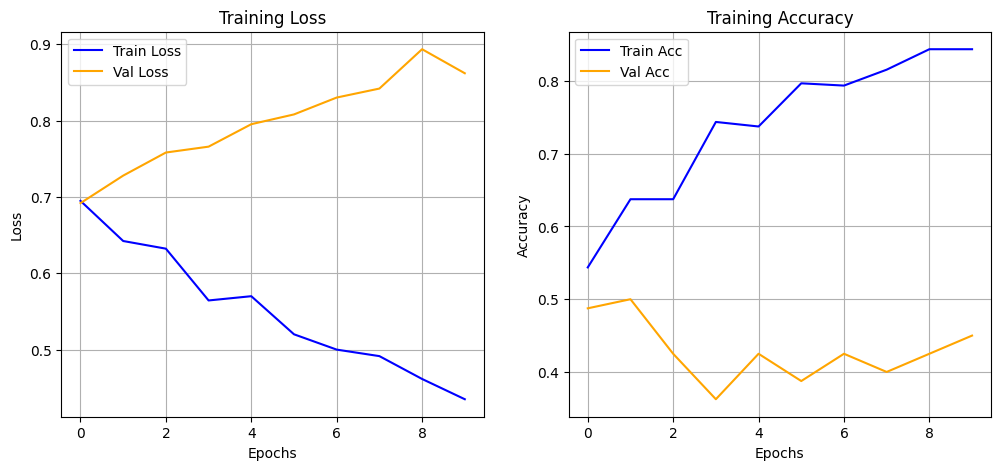

In [12]:
import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load files
print("Scanning folders...")
# Use sorted to guarantee reproducibility
real_paths = sorted(glob.glob("datasets/real/*.mp4"))
fake_paths = sorted(glob.glob("datasets/fake_pyramid/*.mp4"))

# Safety check
if len(real_paths) == 0 or len(fake_paths) == 0:
    print("ERROR: No videos found!")
    print(f"   Real found in 'datasets/real': {len(real_paths)}")
    print(f"   Fake found in 'datasets/fake_pyramid': {len(fake_paths)}")
    raise ValueError("Check the folder paths!")
else:
    print(f"Found {len(real_paths)} Real and {len(fake_paths)} Fake videos.")

# 2. Balancing and labels
# Trim lists to have the same number of Real and Fake (50/50 balanced)
min_len = min(len(real_paths), len(fake_paths))
real_paths = real_paths[:min_len]
fake_paths = fake_paths[:min_len]

all_paths = real_paths + fake_paths
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)  # 0=Real, 1=Fake

# 3. Train/Validation split (80% Train, 20% Val)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Dataset split: {len(train_paths)} Train, {len(val_paths)} Validation")

# 4. Dataset initialization
# NOTE: We pass the full 'real_paths' to train_dataset for Wavelet Augmentation
# The innovation happens here: the dataset will sample from 'real_paths' to mix frequencies
train_dataset = FakeVideoDataset(
    video_paths=train_paths, 
    labels=train_labels, 
    real_video_paths=real_paths,  # Pool for augmentation
    num_frames=NUM_FRAMES,
    is_train=True 
)

val_dataset = FakeVideoDataset(
    video_paths=val_paths, 
    labels=val_labels, 
    real_video_paths=None,  # No augmentation during validation
    num_frames=NUM_FRAMES,
    is_train=False
)

# 5. Dataloaders
# With 8GB of VRAM, batch size 8 is a safe limit. If it crashes, use 4.
BATCH_SIZE = 8 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 6. Model setup
print("\nStarting 3D-ViT training with Wavelet Augmentation...")
model = Detector3DViT().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.head.parameters(), lr=1e-4)

# Lists for plots
train_losses, val_losses = [], []
train_accs, val_accs = [], []

NUM_EPOCHS = 10 

# --- TRAINING LOOP ---
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    # Validate
    v_loss, v_acc = validate(model, val_loader, criterion)
    
    # Store metrics
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    
    print(f"   Train Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"   Val Loss:   {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    
    # Save the model if it is the best so far
    if epoch == 0 or v_acc >= max(val_accs):
        torch.save(model.state_dict(), "models/best_model_3dvit.pth")
        print("   Best model saved.")

print("\nTraining completed.")

# 7. Final plots (copy these into the report)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('results/training_results.png')  # Save the image for the report
plt.show()
